In [80]:
import torch

# Tensors

In [81]:
# Number/Scalar

t1 = torch.tensor(4.)
t1


tensor(4.)

In [82]:
t1.dtype

torch.float32

In [83]:
#Vector
t2 = torch.tensor([1., 2, 3, 4])
t2

tensor([1., 2., 3., 4.])

In [84]:
# Matrix
t3 = torch.tensor([
    [5., 6],
    [7,8],
    [9,10]
])
t3

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.]])

In [85]:
# 3 dimensional array
t4 = torch.tensor([
    [
        [11, 12, 13],
        [14, 15, 16]
    ],
    [
        [17,18,19],
        [20,21,22]
    ]
])

t4

tensor([[[11, 12, 13],
         [14, 15, 16]],

        [[17, 18, 19],
         [20, 21, 22]]])

In [86]:
t4.shape

torch.Size([2, 2, 3])

In [87]:
print(t1)
t1.shape

tensor(4.)


torch.Size([])

In [88]:
print(t2)
t2.shape

tensor([1., 2., 3., 4.])


torch.Size([4])

In [89]:
print(t3)
t3.shape

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.]])


torch.Size([3, 2])

In [90]:
print(t4)
t4.shape

tensor([[[11, 12, 13],
         [14, 15, 16]],

        [[17, 18, 19],
         [20, 21, 22]]])


torch.Size([2, 2, 3])

In [91]:
# Create tensors

x = torch.tensor(3.)
w = torch.tensor(4. , requires_grad = True)
b = torch.tensor(5., requires_grad = True)

x, w, b

(tensor(3.), tensor(4., requires_grad=True), tensor(5., requires_grad=True))

In [92]:
# Arithemitc operations

y = w*x + b
y

tensor(17., grad_fn=<AddBackward0>)

In [93]:
y

tensor(17., grad_fn=<AddBackward0>)

In [94]:
# Compute derivates
y.backward()

In [95]:
# Display gradients
print("dy/dx: " ,x.grad) # basic diffrentiation
print("dy/dw: ", w.grad)
print("dy/db: ", b.grad)


dy/dx:  None
dy/dw:  tensor(3.)
dy/db:  tensor(1.)


In [96]:
t3

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.]])

In [97]:
# Create a tensor with a fixed value for every elemnt

t6 = torch.full((3,2), 42)
t6

tensor([[42, 42],
        [42, 42],
        [42, 42]])

In [98]:
# Concatinate two tensors with compatible shapes
t7 = torch.cat((t3, t6))
t7

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.],
        [42., 42.],
        [42., 42.],
        [42., 42.]])

In [99]:
# change the sin of each element
t8 = torch.sin(t7)
t8

tensor([[-0.9589, -0.2794],
        [ 0.6570,  0.9894],
        [ 0.4121, -0.5440],
        [-0.9165, -0.9165],
        [-0.9165, -0.9165],
        [-0.9165, -0.9165]])

In [100]:
t9 = torch.reshape(t8,(3,2,2))
t9

tensor([[[-0.9589, -0.2794],
         [ 0.6570,  0.9894]],

        [[ 0.4121, -0.5440],
         [-0.9165, -0.9165]],

        [[-0.9165, -0.9165],
         [-0.9165, -0.9165]]])

In [101]:
# change the shape of a tensor

t9 = t8.reshape(3,2,2)
t9

tensor([[[-0.9589, -0.2794],
         [ 0.6570,  0.9894]],

        [[ 0.4121, -0.5440],
         [-0.9165, -0.9165]],

        [[-0.9165, -0.9165],
         [-0.9165, -0.9165]]])

In [102]:
import numpy as np
!pip install pandas
import pandas as pd

x = np.array([[1,2], [3, 4.]])
x


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


array([[1., 2.],
       [3., 4.]])

In [103]:
df=pd.DataFrame(x)
df

,0,1
0,1.0,2.0
1,3.0,4.0


In [104]:
y = torch.from_numpy(x)
y

tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)

In [105]:
x.dtype, y.dtype

(dtype('float64'), torch.float64)

In [106]:
z = y.numpy()
z

array([[1., 2.],
       [3., 4.]])

# Linear Regression from Scratch using pytorch

In [107]:
# Making training data
# Input ---> (temp, rainfall, humidity) ---> yield of apple and oranges crops

inputs = np.array([
    [73, 67,43],
    [91, 88, 64],
    [87, 134, 58],
    [102, 43, 37],
    [69, 96, 70],
], dtype = 'float32')

In [108]:
inputs

array([[ 73.,  67.,  43.],
       [ 91.,  88.,  64.],
       [ 87., 134.,  58.],
       [102.,  43.,  37.],
       [ 69.,  96.,  70.]], dtype=float32)

In [109]:
# Target (apples, oranges)

target = np.array([
    [56, 70],
    [81, 101],
    [119, 113],
    [22, 37],
    [103, 119]
], dtype = 'float32')

In [110]:
target

array([[ 56.,  70.],
       [ 81., 101.],
       [119., 113.],
       [ 22.,  37.],
       [103., 119.]], dtype=float32)

In [111]:
# Convert inputs and target to tensors

inputs = torch.from_numpy(inputs)
target = torch.from_numpy(target)

print(inputs)
print(target)



tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])
tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 113.],
        [ 22.,  37.],
        [103., 119.]])


In [112]:
# Weights and biases
w = torch.randn(2, 3, requires_grad = True)
b = torch.randn(2, requires_grad = True)

print(w)
print(b)


tensor([[ 0.0323, -0.4308,  1.1248],
        [ 1.8085, -0.1453,  0.5427]], requires_grad=True)
tensor([-0.7932, -0.9198], requires_grad=True)


In [113]:
# Z = X * W + B
def model(x):
  return x @ w.t() + b


#    y=x*w(transpose) + b
#   .t() makes the transpose.  @ performs matrix multiplication .. b adds as bias

In [114]:
'''


def modell(input):
    return x@w.t() +b 

pred=model(x)
def erros(y_act,y_pred):
    er=y_act-y_pred
    return er

erros(target,pred)


'''

'\n\n\ndef modell(input):\n    return x@w.t() +b \n\npred=model(x)\ndef erros(y_act,y_pred):\n    er=y_act-y_pred\n    return er\n\nerros(target,pred)\n\n\n'

In [115]:
# prediction
preds = model(inputs)
print(preds)

tensor([[ 21.0656, 144.7011],
        [ 36.2205, 185.5994],
        [  9.5249, 168.4272],
        [ 25.5927, 197.3768],
        [ 38.8125, 147.9072]], grad_fn=<AddBackward0>)


In [116]:
# loss funtion we will use is MSE -> Mean squared error
def MSE(y, y_hat):
  diff = y - y_hat

  return torch.sum(diff*diff)/diff.numel()

In [117]:
# error
loss = MSE(target, preds)
print(loss)

tensor(6170.9155, grad_fn=<DivBackward0>)


In [118]:
#Compute gradients
loss.backward()

In [119]:
print(w)
print(w.grad)

tensor([[ 0.0323, -0.4308,  1.1248],
        [ 1.8085, -0.1453,  0.5427]], requires_grad=True)
tensor([[-4042.3928, -5391.6763, -3015.5637],
        [ 7265.3818,  5909.6489,  3959.7446]])


In [120]:
print(b)
print(b.grad)

tensor([-0.7932, -0.9198], requires_grad=True)
tensor([-49.9568,  80.8023])


In [121]:
#reset grad
w.grad.zero_()
b.grad.zero_()

print(w.grad)
print(b.grad)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([0., 0.])


In [122]:
# Adjust params

preds = model(inputs)

print(preds)


loss = MSE(target, preds)
print(loss)

tensor([[ 21.0656, 144.7011],
        [ 36.2205, 185.5994],
        [  9.5249, 168.4272],
        [ 25.5927, 197.3768],
        [ 38.8125, 147.9072]], grad_fn=<AddBackward0>)
tensor(6170.9155, grad_fn=<DivBackward0>)


In [123]:
w

tensor([[ 0.0323, -0.4308,  1.1248],
        [ 1.8085, -0.1453,  0.5427]], requires_grad=True)

In [124]:
loss.backward()

print(w.grad)
print(b.grad)

tensor([[-4042.3928, -5391.6763, -3015.5637],
        [ 7265.3818,  5909.6489,  3959.7446]])
tensor([-49.9568,  80.8023])


In [125]:
# adjust weight & reset grad

learning_rate = 1e-5

with torch.no_grad():
  w -= w.grad * 1e-5
  b -= b.grad * 1e-5

  w.grad.zero_()
  b.grad.zero_()

In [126]:
print(w)
print(b)

tensor([[ 0.0727, -0.3769,  1.1550],
        [ 1.7358, -0.2044,  0.5031]], requires_grad=True)
tensor([-0.7927, -0.9206], requires_grad=True)


In [127]:
# Calculate again

preds = model(inputs)
loss = MSE(target, preds)
print(loss)

tensor(4731.3633, grad_fn=<DivBackward0>)


In [128]:
for i in range(400):
  preds = model(inputs)
  loss = MSE(target, preds)
  loss.backward()
  with torch.no_grad():
    w -= w.grad * 1e-5
    b -= b.grad * 1e-5

    w.grad.zero_()  # It sets all gradients of w to zero (in-place).
    b.grad.zero_()
  print(f"Epochs({i}/{100}) & Loss {loss}")

Epochs(0/100) & Loss 4731.36328125
Epochs(1/100) & Loss 3754.32275390625
Epochs(2/100) & Loss 3089.049560546875
Epochs(3/100) & Loss 2633.95751953125
Epochs(4/100) & Loss 2320.588623046875
Epochs(5/100) & Loss 2102.8095703125
Epochs(6/100) & Loss 1949.5289306640625
Epochs(7/100) & Loss 1839.7958984375
Epochs(8/100) & Loss 1759.489013671875
Epochs(9/100) & Loss 1699.0921630859375
Epochs(10/100) & Loss 1652.191162109375
Epochs(11/100) & Loss 1614.4619140625
Epochs(12/100) & Loss 1582.990966796875
Epochs(13/100) & Loss 1555.812744140625
Epochs(14/100) & Loss 1531.6025390625
Epochs(15/100) & Loss 1509.466064453125
Epochs(16/100) & Loss 1488.80078125
Epochs(17/100) & Loss 1469.1976318359375
Epochs(18/100) & Loss 1450.3828125
Epochs(19/100) & Loss 1432.168701171875
Epochs(20/100) & Loss 1414.4293212890625
Epochs(21/100) & Loss 1397.0775146484375
Epochs(22/100) & Loss 1380.0552978515625
Epochs(23/100) & Loss 1363.3216552734375
Epochs(24/100) & Loss 1346.8486328125
Epochs(25/100) & Loss 1330.6

In [129]:
preds = model(inputs)
loss = MSE(target, preds)
print(loss)

tensor(50.3218, grad_fn=<DivBackward0>)


In [130]:
from math import sqrt
sqrt(loss)

7.093786029472104

In [131]:
preds

tensor([[ 57.3007,  68.8194],
        [ 86.3801,  96.6161],
        [108.9815, 119.8209],
        [ 23.0556,  48.6017],
        [107.8712, 106.9322]], grad_fn=<AddBackward0>)

In [132]:
target

tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 113.],
        [ 22.,  37.],
        [103., 119.]])

# Fashion MNIST Neural Net example using Pytorch

In [133]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose
import matplotlib.pyplot as plt


ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
# Download training data from open datasets

training_data = datasets.FashionMNIST(
    root = 'data',
    train= True,
    download = True,
    transform = ToTensor(),
)

# Download test data from open datasets

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download = True,
    transform = ToTensor(),
)

100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 5.05MB/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:00<00:00, 55.9MB/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 6.31MB/s]


Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



In [ ]:
type(training_data)

torchvision.datasets.mnist.FashionMNIST

In [ ]:
batch_size = 64

# Create data loaders

train_dataloader = DataLoader(training_data, batch_size = batch_size)
test_dataloader = DataLoader(test_data, batch_size = batch_size)

for X, y in test_dataloader:
  print("Shape of X [N, C, H, W] ", X.shape)
  print("Shape of y: ", y.shape, y.dtype)
  break

Shape of X [N, C, H, W]  torch.Size([64, 1, 28, 28])
Shape of y:  torch.Size([64]) torch.int64


In [ ]:
# Get cpu or gpu device for training

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [ ]:
# Define the NN Model
class NeuralNetwork(nn.Module):

  def __init__(self):
    super(NeuralNetwork, self).__init__()

    self.flatten = nn.Flatten()

    # Hidden Layers with ReLU activation function
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 10) # Output layer
    )

  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits


model= NeuralNetwork().to(device)

print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [ ]:
# Cross Entropy Loss ----> Because it is a multiclass classification problem

loss_fn = nn.CrossEntropyLoss()

# Optimizer ---> SGD ---> Stochastic Gradient Descent
# lr = Learning Rate
optimizer = torch.optim.SGD(model.parameters(), lr = 1e-3)

In [ ]:
# Model Training

def train(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)
  model.train()

  for batch, (X, y) in enumerate(dataloader):
    X, y= X.to(device), y.to(device) # related to gpu computation

    # Compute prediction error
    pred = model(X)
    loss = loss_fn(pred, y)

    # BackPropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch %100 ==0 :
      loss, current = loss.item(), batch * len(X)
      print(f"Loss: {loss} [{current}/{size}]")

In [ ]:
def test(dataloader, model, loss_fn):
  size = len(dataloader.dataset)

  num_batches = len(dataloader)

  model.eval()

  test_loss, correct = 0, 0

  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      pred = model(X)

      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss /= num_batches # average loss per batch
  correct /= size # %age of correct predictions or accuracy

  print(f"Test Error: \n Accuracy: {100*correct} %, Avg loss {test_loss}\n")




In [ ]:
epochs = 1
for t in range(epochs):
  print(f"Epoch {t+1} \n --------------------------")
  train(train_dataloader, model, loss_fn, optimizer)
  test(test_dataloader, model, loss_fn)

print("Done\n")

Epoch 1 
 --------------------------
Loss: 0.7453593611717224 [0/60000]
Loss: 0.8441538214683533 [6400/60000]
Loss: 0.6057318449020386 [12800/60000]
Loss: 0.8170516490936279 [19200/60000]
Loss: 0.730737030506134 [25600/60000]
Loss: 0.6974841952323914 [32000/60000]
Loss: 0.8081368207931519 [38400/60000]
Loss: 0.7774155139923096 [44800/60000]
Loss: 0.7685599327087402 [51200/60000]
Loss: 0.7447283267974854 [57600/60000]
Test Error: 
 Accuracy: 73.24000000000001 %, Avg loss 0.7387217583170362

Done



In [ ]:
#save model
torch.save(model.state_dict(), "model.pth")
print("Saved model state to model.pth")

Saved model state to model.pth


In [ ]:
## Prediction

classes = [
    "T-shirt/top",

"Trouser",

"Pullover",

"Dress",

"Coat",

"Sandal",

"Shirt",

"Sneaker",

"Bag",

"Ankle boot"

]


model.eval()

x, y = test_data[10][0], test_data[10][1]
x = x.to(device)
# y = y.to(device)
with torch.no_grad():
  pred = model(x)
  predicted, actual = classes[pred[0].argmax(0)], classes[y]

  print(f"Predicted: {predicted} Actual: {actual}")




Predicted: Coat Actual: Coat


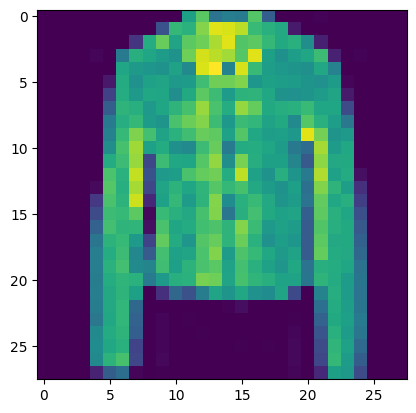

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'x' contains the image data
plt.imshow(x.cpu().squeeze())  # Move tensor to CPU if using GPU
plt.show()